In [2]:
df=pd.read_csv('Downloads/random_stock_market_dataset.csv')

In [3]:
# Import necessary libraries and suppress warnings
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # set backend
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # just in case only plt is imported elsewhere

import seaborn as sns

# For inline plotting in notebooks
%matplotlib inline

# Import sklearn libraries for predictor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Set visual style
sns.set(style='whitegrid')


In [5]:
# Load the stock market dataset
data_path = 'Downloads/random_stock_market_dataset.csv'
df = pd.read_csv(data_path, encoding='ascii')

# Convert Date column to datetime type
# This is crucial as many users might overlook date formatting issues which can result in errors in time series analysis
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Display the first few rows of the dataset
df.head()

,Date,Open,High,Low,Close,Volume
0,2024-01-01,296.45,307.31,293.96,303.72,93133
1,2024-01-02,190.11,193.10,187.21,191.40,64993
2,2024-01-03,197.41,208.64,193.37,205.89,70326
3,2024-01-04,253.13,262.67,248.67,258.95,17358
4,2024-01-05,241.35,253.09,238.99,252.20,20847


### Cleaning data and Preprocessing
* Data cleaning is the process of identifying, correcting, or removing corrupt, inaccurate, duplicated, or irrelevant data points from a dataset. Real-world data is inherently messy; cleaning ensures that your exploratory visualizations and summary statistics reflect true patterns rather than data collection errors.

* Data preprocessing is an umbrella term for taking raw data and transforming its structural state to make it suitable for further computational analysis or machine learning workflows. While data cleaning is technically the first sub-step of preprocessing, preprocessing proper focuses on mathematical and categorical restructuring.

In [6]:
# Check for missing values
missing_values = df.isnull().sum()
print('Missing values in each column:\n', missing_values)

# Drop or impute missing values if any (for demonstration, we'll drop rows with missing dates or prices)
df = df.dropna()

# Verify the data types after cleaning
print('Data types:\n', df.dtypes)

Missing values in each column:
 Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
Data types:
 Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object


### Exploratory Data Analysis

* Exploratory Data Analysis (EDA) is the process of analyzing a dataset to summarize its main characteristics, often using visual methods. It is the critical first step in any data science workflow, performed before applying formal statistical modeling or machine learning algorithms. Instead of making assumptions, a data professional uses EDA to let the data speak for itself, uncovering patterns, spotting anomalies, and checking underlying assumptions.

In [7]:
# Basic descriptive statistics
print('Descriptive Statistics:\n', df.describe())

# Check the date range covered in the dataset
print('Date Range:', df['Date'].min(), 'to', df['Date'].max())

# For numeric correlation analyses, we only use numeric columns
numeric_df = df.select_dtypes(include=[np.number])
print('Numeric columns used for further analysis:', numeric_df.columns.tolist())

Descriptive Statistics:
                       Date        Open        High         Low       Close  \
count                   60   60.000000   60.000000   60.000000   60.000000   
mean   2024-01-30 12:00:00  310.552000  322.589833  308.056833  320.412667   
min    2024-01-01 00:00:00  112.680000  123.780000  109.430000  121.270000   
25%    2024-01-15 18:00:00  222.957500  238.247500  220.042500  237.242500   
50%    2024-01-30 12:00:00  303.240000  313.800000  302.385000  309.385000   
75%    2024-02-14 06:00:00  396.150000  415.915000  392.905000  413.462500   
max    2024-02-29 00:00:00  492.790000  501.670000  492.300000  500.420000   
std                    NaN  108.859051  109.095813  108.986426  109.157159   

              Volume  
count      60.000000  
mean    95405.516667  
min     13193.000000  
25%     48016.500000  
50%     93850.500000  
75%    130917.250000  
max    195189.000000  
std     54895.342146  
Date Range: 2024-01-01 00:00:00 to 2024-02-29 00:00:00
Numeric co

### Visualizations
* Visualization in EDA is the practice of converting raw data into graphical representations to identify patterns, trends, and anomalies that numbers alone cannot easily reveal. It serves as the primary tool for intuitive data discovery during the initial stages of analysis.Instead of scanning thousands of spreadsheet rows, visualization leverages human visual perception to instantly spot relationships, data distributions, and errors.

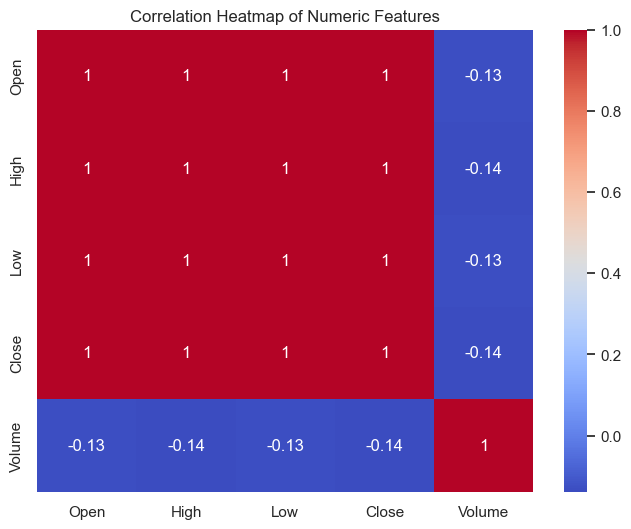

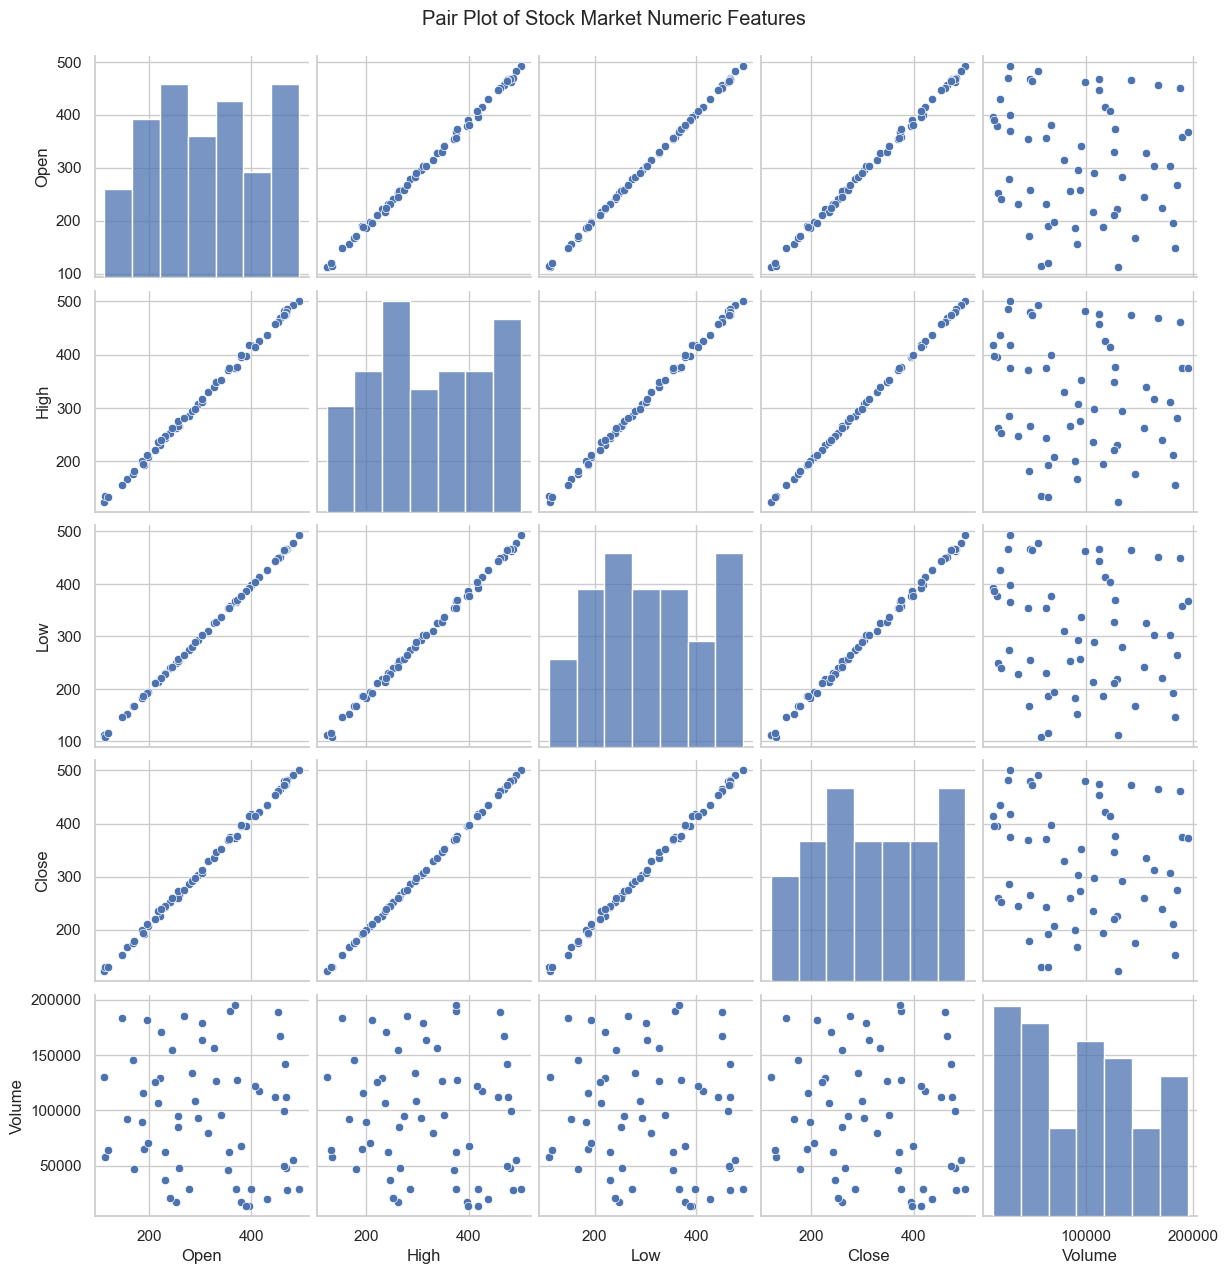

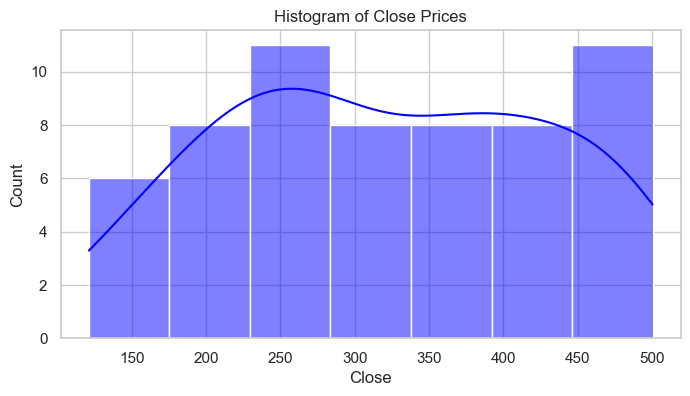

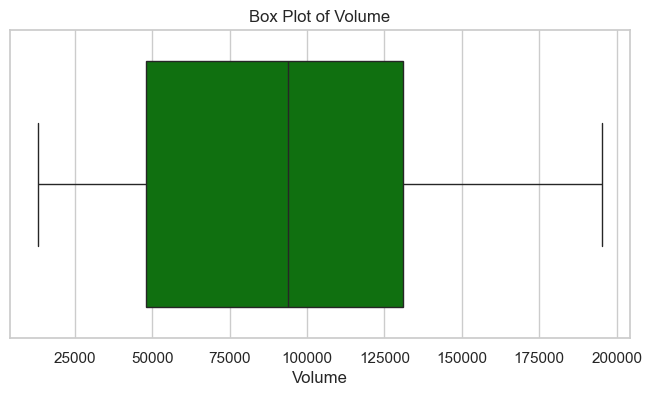

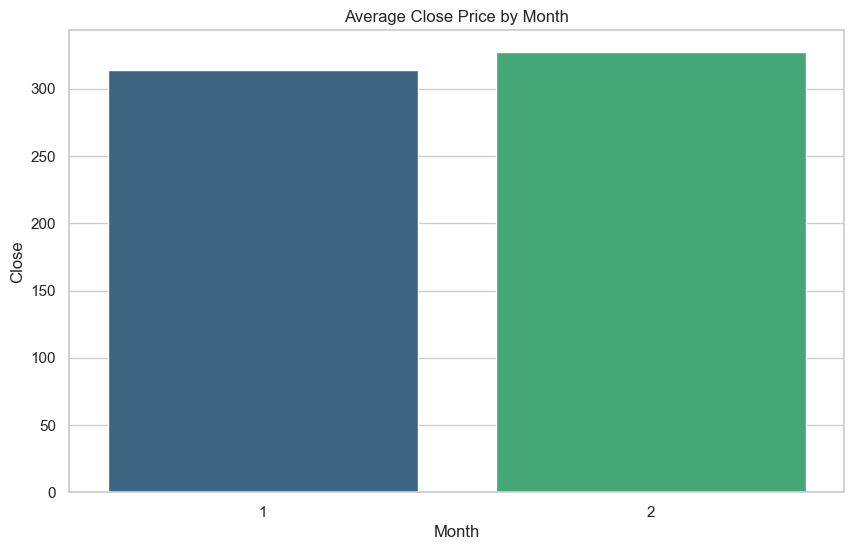

In [10]:
# Correlation Heatmap
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(8, 6))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap of Numeric Features')
    cmap="Spectral"
    plt.show()

# Pair Plot for numeric features
sns.pairplot(numeric_df)
plt.suptitle('Pair Plot of Stock Market Numeric Features', y=1.02)
plt.show()

# Histogram for 'Close' prices
plt.figure(figsize=(8, 4))
sns.histplot(df['Close'], kde=True, color='blue')
plt.title('Histogram of Close Prices')
plt.show()

# Box Plot for 'Volume'
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Volume'], color='green')
plt.title('Box Plot of Volume')
plt.show()

# Bar Plot: Average Close by Month
# Extract month from Date
df['Month'] = df['Date'].dt.month
plt.figure(figsize=(10, 6))
month_avg = df.groupby('Month')['Close'].mean().reset_index()
sns.barplot(x='Month', y='Close', data=month_avg, palette='viridis')
plt.title('Average Close Price by Month')
plt.show()

### Predictor 

In [9]:
# Define features and target variable
features = ['Open', 'High', 'Low', 'Volume']
target = 'Close'

# Split the dataset into training and testing sets
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instantiate and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate the R-squared value to evaluate the model
r2 = r2_score(y_test, y_pred)
print('R-squared score for the predictor:', r2)

# Note: In real-world financial predictions, one might consider more robust models and error metrics.

R-squared score for the predictor: 0.9997790936407334
